# Objective 3 - evaluating the affect of paraphrase transformations to both human and AI generated text

Prior to here I creeated the piplines to extract features from the training dataset for later in training the model etc. But we are back to pipeliens for objective 3, for which we are comparing features after varying levels of paraphrasing. I am therefore now working with the test dataset which has 800 texts (400 each for human and AI), each of which have been lightly paraphrased, heavily paraphrased and back-translation paraphrased. For the purposes of what we are doing here I am going to convert the file into long format so there is just one text per row, and then once that is done I can pass it through the feature extraction piplines to observe how features degrade (presumably!) under heavier levels of paraphrasing.

In [1]:
import re
import numpy as np
import pandas as pd
import stanza
import nltk
import matplotlib.pyplot as plt
from nltk import Tree
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# load data
df = pd.read_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\final_test_dataset.csv"
)

# want to keep order so use this to get orignal position
df["order"] = range(len(df))

# specifc columns to remain unchanged
meta_columns = [
    "document_id",
    "source",
    "topic",
    "label",
    "author"
]

# melt 4 text variations into rows from columns (light heavy etc.)
obj_3_dataset = pd.melt(
    df,
    # keeping metadata and original order
    id_vars = meta_columns + ["order"],
    value_vars = [
        "text",
        "light_paraphrase",
        "heavy_paraphrase",
        "translation_paraphrase"
    ],
    var_name = "condition",
    value_name = "text_content"
)

# rename long text variable names for easier plotting etc later
obj_3_dataset["condition"] = obj_3_dataset["condition"].replace({
    "text" :                   "original",
    "light_paraphrase" :       "light",
    "heavy_paraphrase" :       "heavy",
    "translation_paraphrase" : "translation"
})

# specify order i want these in in the new df
condition_order = {
    "original" :    0,
    "light" :       1,
    "heavy" :       2,
    "translation" : 3
}

# create new order column to allow ordering
obj_3_dataset["text_order"] = (obj_3_dataset["condition"].map(condition_order))
# now sort the df
obj_3_dataset = obj_3_dataset.sort_values(by = ["order", "text_order"])
# rename column back to text                                         
obj_3_dataset = obj_3_dataset.rename(columns = {"text_content" : "text"})
# and can now drop the columns created for ordering
obj_3_dataset = obj_3_dataset.drop(columns = ["order", "text_order"])
# finally reset index after ordering
obj_3_dataset = obj_3_dataset.reset_index(drop = True)

print(obj_3_dataset.shape)
print(obj_3_dataset["condition"].value_counts())  
print(obj_3_dataset["text"].isna().sum())
obj_3_dataset.head(10)

(3192, 7)
condition
original       798
light          798
heavy          798
translation    798
Name: count, dtype: int64
0


,document_id,source,topic,label,author,condition,text
0,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,original,A lot of the reviews/testimonials I see claim ...
1,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,light,Many of the reviews/testimonials I see claim t...
2,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,heavy,Many of the reviews and testimonials I have re...
3,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,translation,Many of the reviews and testimonials I see cla...
4,HU_GUT_0289,Gutenberg,Mystery,0,human,original,More carriages passed through the lodge-gates ...
5,HU_GUT_0289,Gutenberg,Mystery,0,human,light,More carriages passed through the lodge-gates ...
6,HU_GUT_0289,Gutenberg,Mystery,0,human,heavy,In the first weeks following Squire Denison’s ...
7,HU_GUT_0289,Gutenberg,Mystery,0,human,translation,More cars passed through the lodge gates durin...
8,AI_WIK_0040,Wikipedia,history,1,AI,original,The Antikythera mechanism is an ancient Greek ...
9,AI_WIK_0040,Wikipedia,history,1,AI,light,The Antikythera mechanism is an ancient Greek ...


Now have a 3192 length file to save which can then be run through the pipelines.

____________


Now I can copy over the piplines - surface, syntactic, semantic, and their helper / cleaning functions to enable me to extract the three features groups from this dataset which contains original text plus paraphrases.

___

## Surface feature extraction of paraphrased data for objective 3

In [12]:
def surface_pipe_clean(text):
    # if text is missing return a blank ""
    if pd.isna(text):
        return ""
    # convert text to string if not already
    text = str(text)
    # remove any html markup still existing
    text = re.sub(r"<[^>]+>", " ", text)
    # change any multiple spaces, tabs, newlines with " "
    text = re.sub(r"\s+", " ", text)
    # strip outside whitespace
    text = text.strip()
    # return cleaned text
    return text

In [13]:
defined_function_words = [
    "a", "all", "also", "an", "and", "any", "are", "as", "at", "be", "been", "but", "by", "can", "do", "down", "even", "every", "for",
    "from", "had", "has", "have", "her", "his", "if", "in", "into", "is", "it", "its", "may", "more", "must", "my", "no", "not", "now",
    "of", "on", "one", "only", "or", "our", "shall", "should", "so", "some", "such", "than", "that", "the", "their", "then", "there",
    "things", "this", "to", "up", "upon", "was", "were", "what", "when", "which", "who", "will", "with", "would", "your"
]

In [14]:
def mtld_calc(tokens, threshold = 0.72):
    # return 0 if no tokens
    if len(tokens) == 0:
        return 0
    # initalise empty set to store unique words
    types = set()
    # initialise tokens in current factor
    factor_tokens = 0
    # and total factors
    factors = 0
    # now loop through tokens
    for token in tokens:
        # add token to set
        types.add(token)
        # incremenet count
        factor_tokens += 1
        # and calcualte current TTR
        current_ttr = len(types) / factor_tokens
        # finally check whether threshold has been reached
        if current_ttr <= threshold:
            # increment factors
            factors += 1
            # reset set of unique words
            types = set()
            # and reset the factor tokens
            factor_tokens = 0
    # after final factor check to see if there are tokens remaining
    if factor_tokens > 0:
        # get TTR of final partial factor
        current_ttr = len(types) / factor_tokens
        # calculate fraction of final fractor
        final_factor = ((1 - current_ttr) / (1 - threshold))
        # add the partial factor to the total
        factors += final_factor
    # get final mtld if not 0
    if factors > 0:
        mtld = len(tokens) / factors
    else:
        mtld = 0
    # return mtld score
    return mtld   

In [15]:
def extract_surface_features(text):

    # run cleaning function
    text = surface_pipe_clean(text)
    # return empty dict if no text
    if not text:
        return {}
    
    ##################################
    # Words
    ##################################

    # tokenize text into words and punct
    all_tokens = word_tokenize(text)
    # trim to words only
    words = [
        token for token in all_tokens 
        if token.isalpha()
    ]
    # make all words lowercase to not duplicate the and The etc.
    words = [
        word.lower() 
        for word in words
    ]
    # finally count tot of all words
    word_count = len(words)
    # also count all chars inc. punct and " "
    # whilst here, needed later for ratios
    char_count = len(text)
    # get length of all words
    word_lengths = [
        len(word) for word in words
    ]
    # get average word length
    mean_word_length = (
        np.mean(word_lengths) 
        if word_lengths 
        else 0
    )
    # get STD of word lengths
    std_word_length = (
        np.std(word_lengths) 
        if word_lengths 
        else 0
    )


    ##################################
    # Sentences
    ##################################

    # tokenise sentences
    sentences = sent_tokenize(text)
    # count them
    sentence_count = len(sentences)
    # get num of words in each sentence
    sentence_lengths = [
        len([
            token for token in word_tokenize(sentence)
            if token.isalpha()
        ])
        for sentence in sentences
    ]
    # Get average sentence length
    mean_sentence_length = (
        np.mean(sentence_lengths) 
        if sentence_lengths 
        else 0
    )
    # get STD of sentence lengths
    std_sentence_length = (
        np.std(sentence_lengths) 
        if sentence_lengths 
        else 0
    )


    ##################################
    # Word frequencies
    ##################################

    # These are used in the calculations for  ratios etc.
    # get word counts of every word
    word_counts = Counter(words)
    # calculate num of different words used
    vocab_size = len(word_counts)


    ##################################
    # Ratios
    ##################################

    # calculate Root of type token ratio (TTR)
    root_ttr = (
        vocab_size / np.sqrt(word_count)
        if word_count > 0 
        else 0
    )
    # calculate Hapax legomena
    # hapax legomena count - words occuring only once
    hapax_l_count = sum(
        1 for frequency in word_counts.values()
        if frequency == 1
    )
    # hapax l ratio (hapax words / all)
    hapax_l_ratio = (
        hapax_l_count / word_count
        if word_count > 0 
        else 0
    )
    # calculate hapax dislegomena
    # count - words appearing twice
    hapax_d_count = sum(
        1 for frequency in word_counts.values()
        if frequency == 2
    )
    # hapax d ratio (hapax words / all)
    hapax_d_ratio = (
        hapax_d_count / word_count
        if word_count > 0 
        else 0
    )
    # calculate Yuke's K - vocab repetition
    # get sum of squared word freq
    sum_square_freq = sum(
        freq ** 2
        for freq in word_counts.values()
    )
    # calculate Yules K measure
    yules_k = (
        10000 * (sum_square_freq - word_count) / (word_count ** 2)
        if word_count > 0 
        else 0
    )
    # calculate mtld
    mtld = mtld_calc(words)


    ##################################
    # Function word frequencies
    ##################################

    # initialise empty dict
    function_word_ratios = {}
    # loop through pre-defined function words
    for function_word in defined_function_words:
        # assign f sting name
        function_word_ratios[f"func_ratio_{function_word}"] = (
            # assign value of function word count / total
            word_counts[function_word] / word_count
            if word_count > 0 
            else 0
        )


    ##################################
    # Punctation
    ##################################

    # counts of all common punctuation types
    comma_count =       text.count(",")
    colon_count =       text.count(":")
    semicolon_count =   text.count(";")
    question_count =    text.count("?")
    exclamation_count = text.count("!")
    hyphen_count =      text.count("-")
    endash_count =      text.count("–")
    emdash_count =      text.count("—")

    # ratios for all the above / total characters in text
    comma_ratio = (
        comma_count / char_count 
        if char_count > 0 
        else 0
    )
    colon_ratio = (
        colon_count / char_count 
        if char_count > 0 
        else 0
    )
    semicolon_ratio = (
        semicolon_count / char_count 
        if char_count > 0 
        else 0
    )
    question_ratio = (
        question_count / char_count 
        if char_count > 0 
        else 0
    )
    exclamation_ratio = (
        exclamation_count / char_count 
        if char_count > 0 
        else 0
    )
    hyphen_ratio = (
        hyphen_count / char_count 
        if char_count > 0 
        else 0
    )
    endash_ratio = (
        endash_count / char_count 
        if char_count > 0 
        else 0
    )
    emdash_ratio = (
        emdash_count / char_count 
        if char_count > 0 
        else 0
    )


    ##################################
    # Character types
    ##################################

    # count alphabetic
    alpha_count = sum(
        1 for character in text
        if character.isalpha()
    )
    # count uppercase
    upper_count = sum(
        1 for character in text
        if character.isupper()
    )
    # count lowercase
    lower_count = sum(
        1 for character in text
        if character.islower()
    )
    # count digits
    digit_count = sum(
        1 for character in text
        if character.isdigit()
    )
    # count whitespaces
    space_count = sum(
        1 for character in text
        if character.isspace()
    )
    # count punctuation, i.e. not alphanumeric or " "
    punct_count = sum(
        1 for character in text
        if not character.isalnum()
        and not character.isspace()
    )
    
    # as above, ratios for all the above / total chars in text
    alpha_ratio = (
        alpha_count / char_count 
        if char_count > 0 
        else 0
    )
    upper_ratio = (
        upper_count / char_count 
        if char_count > 0 
        else 0
    )
    lower_ratio = (
        lower_count / char_count 
        if char_count > 0 
        else 0
    )
    digit_ratio = (
        digit_count / char_count 
        if char_count > 0 
        else 0
    )
    space_ratio = (
        space_count / char_count 
        if char_count > 0 
        else 0
    )
    punct_ratio = (
        punct_count / char_count 
        if char_count > 0 
        else 0
    )


    ##################################
    # Storage
    ##################################

    # now need to store all variables gathered in the pipeline
    surface_features = {

        # Totals
        "word_count" :           word_count,
        "character_count" :      char_count,
        "sentence_count" :       sentence_count,
        
        # Words
        "mean_word_length" :     mean_word_length,
        "std_word_length" :      std_word_length,

        # Sentences
        "mean_sentence_length" : mean_sentence_length,
        "std_sentence_length" :  std_sentence_length,

        # Lexical diversity features
        "root_ttr" :             root_ttr,
        "hapax_l_ratio" :        hapax_l_ratio,
        "hapax_d_ratio" :        hapax_d_ratio,
        "yules_k" :              yules_k,
        "mtld" :                 mtld,

        # Punctuation
        "comma_ratio" :          comma_ratio,
        "colon_ratio" :          colon_ratio,
        "semicolon_ratio" :      semicolon_ratio,
        "question_ratio" :       question_ratio,
        "exclamation_ratio" :    exclamation_ratio,
        "hyphen_ratio" :         hyphen_ratio,
        "endash_ratio" :         endash_ratio,
        "emdash_ratio" :         emdash_ratio,

        # Characters
        "alpha_ratio" :          alpha_ratio,
        "upper_ratio" :          upper_ratio,
        "lower_ratio" :          lower_ratio,
        "digit_ratio" :          digit_ratio,
        "space_ratio" :          space_ratio,
        "punct_ratio" :          punct_ratio

    }
    
    # Function words
    # Finally add on all the function word ratios
    surface_features.update(function_word_ratios)

    # ...and return all features
    return surface_features

____

## Extracting surface features from paraphrased data

In [17]:
# run surface feature extraction on first 20 texts to ensure it works as expected
obj_3_surface = pd.DataFrame(
    obj_3_df["text"].apply(
        extract_surface_features
    # and convert to list of dicts
    ).to_list()
)

# retain the metadata so we can still identify id, paraphrase type etc
obj_3_surface = pd.concat(
    [
        obj_3_df[
        ["document_id", "source", "topic", "label", "author", "condition"]
    ].reset_index(drop = True),
        obj_3_surface
    ],
    axis = 1
)

# check output
print(obj_3_surface.shape)
print(obj_3_surface.isna().sum().sum())
print(obj_3_surface.dtypes.value_counts())
obj_3_surface.head(10)

(3192, 102)
0
float64    93
object      5
int64       4
Name: count, dtype: int64


,document_id,source,topic,label,author,condition,word_count,character_count,sentence_count,mean_word_length,...,func_ratio_was,func_ratio_were,func_ratio_what,func_ratio_when,func_ratio_which,func_ratio_who,func_ratio_will,func_ratio_with,func_ratio_would,func_ratio_your
0,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,original,336,1978,15,4.312500,...,0.005952,0.002976,0.002976,0.000000,0.005952,0.002976,0.000000,0.005952,0.005952,0.002976
1,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,light,341,2042,14,4.568915,...,0.002933,0.002933,0.002933,0.000000,0.005865,0.005865,0.002933,0.005865,0.005865,0.002933
2,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,heavy,375,2331,21,4.970667,...,0.005333,0.002667,0.000000,0.000000,0.002667,0.008000,0.005333,0.013333,0.005333,0.002667
3,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,translation,363,2079,14,4.482094,...,0.002755,0.002755,0.002755,0.000000,0.008264,0.005510,0.005510,0.008264,0.005510,0.002755
4,HU_GUT_0289,Gutenberg,Mystery,0,human,original,411,2350,21,4.452555,...,0.019465,0.012165,0.002433,0.000000,0.004866,0.002433,0.000000,0.007299,0.012165,0.002433
5,HU_GUT_0289,Gutenberg,Mystery,0,human,light,394,2312,21,4.614213,...,0.020305,0.015228,0.002538,0.000000,0.007614,0.002538,0.000000,0.005076,0.010152,0.000000
6,HU_GUT_0289,Gutenberg,Mystery,0,human,heavy,395,2498,23,5.075949,...,0.010127,0.015190,0.002532,0.000000,0.005063,0.002532,0.000000,0.007595,0.007595,0.000000
7,HU_GUT_0289,Gutenberg,Mystery,0,human,translation,429,2453,21,4.578089,...,0.018648,0.009324,0.002331,0.000000,0.006993,0.002331,0.000000,0.006993,0.016317,0.000000
8,AI_WIK_0040,Wikipedia,history,1,AI,original,407,2834,19,5.769042,...,0.007371,0.000000,0.000000,0.002457,0.004914,0.000000,0.000000,0.012285,0.000000,0.000000
9,AI_WIK_0040,Wikipedia,history,1,AI,light,412,2791,19,5.582524,...,0.004854,0.002427,0.000000,0.002427,0.004854,0.000000,0.000000,0.007282,0.000000,0.000000


Can now save this and move onto syntactic features.

In [18]:
obj_3_surface.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_surface_features.csv", 
    index = False
)

___

## Syntactic feature extraction of paraphrased data for objective 3

In [20]:
stan_pipe = stanza.Pipeline(
    lang = "en",
    # need these processors for feature extraction later
    # don't actually need lemmatisation but that is needed for depparse
    processors = "tokenize, pos, lemma, depparse, constituency",
    use_gpu = False,
    verbose = False
)

In [21]:
def syntactic_pipe_clean(text):
    # if text is missing return a blank ""
    if pd.isna(text):
        return ""
    # convert text to string if not already
    text = str(text)
    # remove any html markup still existing
    text = re.sub(r"<[^>]+>", " ", text)
    # change any multiple spaces, tabs, newlines with " "
    text = re.sub(r"\s+", " ", text)
    # strip outside whitespace
    text = text.strip()
    # return cleaned text
    return text

In [22]:
def get_dep_depth(word_id, paths):
    # initialise depth = 0
    depth = 0
    # and begin with current word
    current = word_id
    while (
        # check current word exists in dict of heads
        current in paths
        # and continue until head of current word = 0, i.e. root
        and paths[current] != 0
    ):
        # every iteration increment depth
        depth += 1
        # and move up a level to head of current word
        current = paths[current]
    # return depth of current word
    return depth

In [23]:
bigrams = pd.read_csv("final_chosen_bigrams.csv")
chosen_bigrams_list = list(
    bigrams[["pos_1", "pos_2"]]
    .itertuples(index = False, name = None)
)

In [24]:
def extract_syntactic_features_3(text):

    # run cleaning function
    text = syntactic_pipe_clean(text)
    # return empty dict if no text
    if not text:
        return {}

    # run text through stanza pipeline to parse
    text = stan_pipe(text)

    # get total sentences - this is used multiple times below
    num_sentences = len(text.sentences)

    
    ##################################
    # POS features
    ##################################

    # initialise counters for pos tags
    pos_counts = Counter()
    pos_bigrams = Counter()
    # pos_trigrams = Counter() too many features - delete later?
    # counter for total tokens to calculate ratios
    total_tokens = 0

    # loop through sentences in text
    for sentence in text.sentences:

        # create empty list for POS tags in current setnence
        sentence_pos_tags = []

        ##################################
        # POS tag counts
        ##################################

        # getting pos tags in current sentence
        # loop through words in sentence
        for word in sentence.words:

            # get POS tag for current word
            pos_tag = word.upos
            # increment total for that POS tag
            pos_counts[pos_tag] += 1
            # add current pos tag to list for this sentence
            sentence_pos_tags.append(pos_tag)
            # increment tokens processed
            total_tokens += 1

        ##################################
        # POS bigrams
        ##################################

        # now looking at bigrams
        # loop through all POS tags in current sentence (except last) 
        for i in range(len(sentence_pos_tags) - 1):
            # and take the bigram from each, that is, current tag + next
            bigram = (
                sentence_pos_tags[i],
                sentence_pos_tags[i + 1]
            )
            # and now check whether that bigram is in our list of chosen bigrams
            if bigram in chosen_bigrams_list:
                
                # ...if so, increment the freq of this bigram
                pos_bigrams[bigram] += 1

    # now get the totals
    total_bigrams = sum(pos_bigrams.values())
    # total_trigrams = sum(pos_trigrams.values()) - too many features, removed, delete later?
    

    
    ##################################
    # Constituency features
    ##################################

    # set counter for storing phrase counts
    phrase_counts = Counter()
    # and list for parse tree depths
    parse_tree_depths = []
    # and specify phrases to measue where i.e. NP is noun phrase etc.
    target_phrases = {"NP", "VP", "PP", "ADJP", "ADVP"}

    # loop through sentences in text
    for sentence in text.sentences:

        # convert stansa parse tree to nltk tree to use nltk methods
        constituency_tree = Tree.fromstring(
            str(sentence.constituency)
        )
        # get height of tree and add to list of depths
        parse_tree_depths.append(
            constituency_tree.height()
        )
        # now loop through subtrees in tree...
        for subtree in constituency_tree.subtrees():
            # ...and get its label (NP etc.)
            phrase_label = subtree.label()
            # if label is one of those above in target
            if phrase_label in target_phrases:
                # increment it
                phrase_counts[phrase_label] += 1

    # now get total
    mean_parse_tree_depth = (
        np.mean(parse_tree_depths)
        if parse_tree_depths
        else 0
    )

    
    ##################################
    # Clause features
    ##################################

    # set empty list to store clausal dependents in each sentence
    clausal_dep_per_sent = []
    # initialise counter for sentences with at least 1
    sents_with_clausal_dep = 0
    # define the relations that represent clausal dependent strauctures
    # i.e. csubj = clausal subject
    clausal_relations = {"acl", "advcl", "ccomp", "csubj", "xcomp"}

    # loop through sentences in text
    for sentence in text.sentences:

        # ...and count the words whose dependency relation is listed above
        dep_clause_count = sum(
            # initially returned too much info, here we now collapse sub-types
            word.deprel.split(":")[0] in clausal_relations
            for word in sentence.words
        )
        # add that number to list
        clausal_dep_per_sent.append(dep_clause_count)
        # confirm there is at least one
        if dep_clause_count > 0:
            # if so increment sentences that have a clausal dependent
            sents_with_clausal_dep += 1

    # now get totals
    mean_clausal_dep_per_sent = (
        np.mean(clausal_dep_per_sent)
        if clausal_dep_per_sent
        else 0
    )
    sent_with_clausal_dep_ratio = (
        sents_with_clausal_dep / num_sentences
        if num_sentences > 0
        else 0
    )

    
    ##################################
    # Production rule features
    ##################################

    # this created way too many features...
    # ...and whilst we don't want to omit this category, we now switch to 
    # mean production rules per sentence, solely to keep output manageable

    # initialise empty list
    prod_rules_per_sent = []

    # loop through sentences in text
    for sentence in text.sentences:
    
        # convert stanza parse to NLTK tree
        nltk_tree = Tree.fromstring(str(sentence.constituency))
        # set counter to 0 for this sentence
        sent_prod_rule_count = 0
        
        # and now get the production rules
        for production in nltk_tree.productions():
        
            # lexical rules retain words from the text on the right hand side
            # not only do we are measuring syntactic strusture and not vocabulary
            # but this results in hundreds of additional features
            if not production.is_lexical():

                # if we find a production rule, increment the count
                sent_prod_rule_count += 1

        # add the sentence prod rule count to the lsit
        prod_rules_per_sent.append(sent_prod_rule_count)

    # and finally calculate the mean
    mean_prod_rules_per_sent = (
        np.mean(prod_rules_per_sent)
        if prod_rules_per_sent
        else 0
    )

    
    ##################################
    # Dependency features
    ##################################

    # set counter to store freq of dependency relations
    dep_rel_counts = Counter()
    # set empty list to store ave. dependency depths
    dep_depths = []
    # set empty list to store distances between each word and head
    dep_distances = []
    
    # loop through sentences in text
    for sentence in text.sentences:

        # loop through words in sentence
        for word in sentence.words:

            # this initally resulted in massive numbers of features due to subtypes
            # so we want to collapse the relation to just the main relation
            collapsed_rel = (word.deprel.split(":")[0])
            # and for each increment count
            dep_rel_counts[collapsed_rel] += 1
        
            # now for distances...
            # exclude the root (0) because it cannot have a head 
            # and therefore no distance to the head
            if word.head != 0:

                # then get distance between word and head
                # abs to ensure positive
                dep_distance = abs(word.id - word.head)
                # store it
                dep_distances.append(dep_distance)

        
        # now for tree depth
        # loop through each word in the sentence and for each 
        # create an entry that is "that word id" : "word head id"
        paths = {
            word.id : word.head
            for word in sentence.words
        }
        # create empty list for dependency depths for each word
        sent_dep_depths = []

        # now loop through each word in sentence
        for word in sentence.words:
            # get depth of current word and store
            depth = get_dep_depth(word.id, paths)
            sent_dep_depths.append(depth)

        # finally get average dependency depth
        if sent_dep_depths:
            dep_depths.append(np.mean(sent_dep_depths))

    # now get totals
    tot_dependencies = sum(
        dep_rel_counts.values()
    )
    mean_dep_depth = (
        np.mean(dep_depths)
        if dep_depths
        else 0
    )
    mean_dep_distance = (
        np.mean(dep_distances)
        if dep_distances
        else 0
    )


    ##################################
    # Storage
    ##################################

    # now need to store all variables gathered in the pipeline
    # start a dict here with what we have already
    syntactic_features = {

        # constituency
        "mean_parse_tree_depth" :       mean_parse_tree_depth,

        # clausal dependent
        "mean_clausal_dep_per_sent" :   mean_clausal_dep_per_sent,
        "sent_with_clausal_dep_ratio" : sent_with_clausal_dep_ratio,
        
        # production rule
        # "prod_rule_diversity" :      prod_rule_diversity, removed delete later???
        "mean_prod_rules_per_sent" :   mean_prod_rules_per_sent,
        
        # dependency
        "mean_dep_depth" :              mean_dep_depth,
        "mean_dep_distance" :           mean_dep_distance
    
    }

    ##################################
    # Storage of additional features
    ##################################

    
    # define list of possible pos tags
    pos_tag_list = [
        "ADJ", "ADP", "ADV", "AUX", "CCONJ",
        "DET", "INTJ", "NOUN", "NUM", "PART",
        "PRON", "PROPN", "PUNCT", "SCONJ", "SYM", 
        "VERB", "X"
    ]

    # POS tag ratios
    if total_tokens > 0:

        # loop through all possible pos tags 
        for pos_tag in pos_tag_list:

            # get count
            count = pos_counts[pos_tag]
            
            # and store ratio of count / total as "pos_ratio_tag"
            syntactic_features[f"pos_ratio_{pos_tag}"] = (
                count / total_tokens
            )

    # POS bigram frequencies
    # loop through list of chosen bigrams
    for bigram in chosen_bigrams_list:
        
        # and get the count of it, if doesn't exist return 0
        count = pos_bigrams.get(bigram, 0)

        # and store ratio of count / total as "pos_bigram_word1_word2"
        syntactic_features[f"pos_bigram_{bigram[0]}_{bigram[1]}"] = (
            count / total_bigrams
            if total_bigrams > 0
            else 0
        )
    
    # phrase type frequencies
    if num_sentences > 0:

        # loop through all phrase targets 
        for phrase in target_phrases:

            # get count
            count = phrase_counts[phrase]
            
            # and store ratio of count / total as "phrase_per_sent_"phrase""
            syntactic_features[f"phrase_per_sent_{phrase}"] = (
                count / num_sentences
            )

    # dependency relation frequencies

    dependency_relation_list = [
        "acl", "advcl", "advmod", "amod", "appos", "aux", "case", "cc",
        "ccomp", "clf", "compound", "conj", "cop", "csubj", "dep", "det",
        "discourse", "dislocated", "expl", "fixed", "flat", "iobj", "mark",
        "nmod", "nsubj", "nummod", "obj", "obl", "orphan", "parataxis", 
        "punct", "reparandum", "root", "vocative", "xcomp"
    ]
       
    if tot_dependencies > 0:

        # loop through all relation counts 
        for relation in dependency_relation_list:
            
            # get count
            count = dep_rel_counts[relation]
            # and store ratio of count / total as "dependency_ratio_'relation'"
            syntactic_features[f"dependency_ratio_{relation}"] = (
                count / tot_dependencies
            )
    
    # ...and return all features
    return syntactic_features

____

## Extracting syntactic features from paraphrased data

Tweaking the save step to print progress and save every 100 rows as when I ran this pipline previously it took ~ 24 hours.

In [27]:
# empty list to temporarily store features
syntactic_features = []
# output temp file to store progress regularly
output = "obj_3_syntactic_temp.csv"

# loop through text column in df
for i, text in enumerate(obj_3_df["text"], start = 1):
    
    # for each row get the syntactic features of the text
    syntactic_features.append(
        extract_syntactic_features_3(text)
    )

    # every 100 texts / final text
    if i % 100 == 0 or i == len(obj_3_df):

        # convert all features so far into DF
        features_df = pd.DataFrame(syntactic_features)

        # and keep also the matching metadata 
        meta_df = (
            obj_3_df[
                ["document_id", "source", "topic", "label", "author", "condition"]
            ]
            .iloc[:i]
            .reset_index(drop = True)
        )

        # combine the seperate features and metadata DFs
        obj_3_syntactic = pd.concat(
            [meta_df, features_df],
            axis = 1
        )

        # save to csv, overwriting previous
        obj_3_syntactic.to_csv(output, index = False)
        # and print a progress update
        print(f"Progress: {i} / {len(obj_3_df)}")



# check output
print(obj_3_syntactic.shape)
print(obj_3_syntactic.isna().sum().sum())
print(obj_3_syntactic.dtypes.value_counts())
obj_3_syntactic.head(10)

Progress: 100 / 3192
Progress: 200 / 3192
Progress: 300 / 3192
Progress: 400 / 3192
Progress: 500 / 3192
Progress: 600 / 3192
Progress: 700 / 3192
Progress: 800 / 3192
Progress: 900 / 3192
Progress: 1000 / 3192
Progress: 1100 / 3192
Progress: 1200 / 3192
Progress: 1300 / 3192
Progress: 1400 / 3192
Progress: 1500 / 3192
Progress: 1600 / 3192
Progress: 1700 / 3192
Progress: 1800 / 3192
Progress: 1900 / 3192
Progress: 2000 / 3192
Progress: 2100 / 3192
Progress: 2200 / 3192
Progress: 2300 / 3192
Progress: 2400 / 3192
Progress: 2500 / 3192
Progress: 2600 / 3192
Progress: 2700 / 3192
Progress: 2800 / 3192
Progress: 2900 / 3192
Progress: 3000 / 3192
Progress: 3100 / 3192
Progress: 3192 / 3192
(3192, 103)
0
float64    97
object      5
int64       1
Name: count, dtype: int64


,document_id,source,topic,label,author,condition,mean_parse_tree_depth,mean_clausal_dep_per_sent,sent_with_clausal_dep_ratio,mean_prod_rules_per_sent,...,dependency_ratio_nummod,dependency_ratio_obj,dependency_ratio_obl,dependency_ratio_orphan,dependency_ratio_parataxis,dependency_ratio_punct,dependency_ratio_reparandum,dependency_ratio_root,dependency_ratio_vocative,dependency_ratio_xcomp
0,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,original,12.235294,2.117647,0.764706,23.176471,...,0.007009,0.044393,0.042056,0.0,0.009346,0.142523,0.0,0.039720,0.000000,0.023364
1,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,light,11.705882,2.176471,0.764706,22.470588,...,0.004773,0.047733,0.035800,0.0,0.011933,0.145585,0.0,0.040573,0.000000,0.023866
2,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,heavy,11.272727,1.590909,0.863636,18.045455,...,0.004587,0.050459,0.048165,0.0,0.009174,0.123853,0.0,0.050459,0.000000,0.020642
3,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,translation,13.133333,2.666667,0.866667,26.533333,...,0.002336,0.051402,0.039720,0.0,0.014019,0.142523,0.0,0.035047,0.000000,0.025701
4,HU_GUT_0289,Gutenberg,Mystery,0,human,original,12.190476,1.857143,0.761905,21.285714,...,0.004158,0.035343,0.058212,0.0,0.002079,0.124740,0.0,0.043659,0.002079,0.022869
5,HU_GUT_0289,Gutenberg,Mystery,0,human,light,11.857143,1.809524,0.761905,20.476190,...,0.004348,0.045652,0.047826,0.0,0.006522,0.123913,0.0,0.045652,0.002174,0.026087
6,HU_GUT_0289,Gutenberg,Mystery,0,human,heavy,11.782609,1.608696,0.782609,18.304348,...,0.004357,0.043573,0.065359,0.0,0.006536,0.119826,0.0,0.050109,0.002179,0.026144
7,HU_GUT_0289,Gutenberg,Mystery,0,human,translation,12.333333,1.904762,0.761905,21.666667,...,0.004124,0.041237,0.063918,0.0,0.008247,0.111340,0.0,0.043299,0.002062,0.024742
8,AI_WIK_0040,Wikipedia,history,1,AI,original,12.578947,1.368421,0.947368,20.157895,...,0.010893,0.050109,0.052288,0.0,0.000000,0.091503,0.0,0.041394,0.000000,0.006536
9,AI_WIK_0040,Wikipedia,history,1,AI,light,12.263158,1.263158,0.894737,20.315789,...,0.010776,0.056034,0.047414,0.0,0.000000,0.090517,0.0,0.040948,0.000000,0.006466


In [29]:
obj_3_syntactic.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_syntactic_features.csv", 
    index = False
)

___

## Semantic feature extraction of paraphrased data for objective 3

In [31]:
# initialise sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

This Stanza pipeline is very similar to the one used previously, however for syntactic we additionally used depparse and constituency processors whch aren't needed here and so we remove to speed up processing.

In [32]:
# initialise stanza nlp pipeline
stan_pipe = stanza.Pipeline(
    processors = "tokenize, pos, lemma",
    use_gpu = False,
    verbose = False
)

In [33]:
def stanza_to_wordnet(upos):
    # check for stanza noun tag
    if upos == "NOUN":
        # if noun, return wordnet noun
        return wordnet.NOUN
    # repeat for other chosen tags
    elif upos == "VERB":
        return wordnet.VERB
    elif upos == "ADV":
        return wordnet.ADV
    elif upos == "ADJ":
        return wordnet.ADJ
    # if not predefined tag, return none and exclude token
    else:
        return None

In [34]:
def semantic_pipe_clean(text):
    # if text is missing return a blank ""
    if pd.isna(text):
        return ""
    # convert text to string if not already
    text = str(text)
    # remove any html markup still existing
    text = re.sub(r"<[^>]+>", " ", text)
    # change any multiple spaces, tabs, newlines with " "
    text = re.sub(r"\s+", " ", text)
    # strip outside whitespace
    text = text.strip()
    # return cleaned text
    return text

In [35]:
def extract_semantic_features(text):

    # run cleaning function
    text = semantic_pipe_clean(text)
    # return empty dict if no text
    if not text:
        return {}

    # run text through stanza pipeline to parse
    text = stan_pipe(text)

    # set counter to track relevent tokens (noun etc)
    rel_tokens = 0
    # track relevent tokens with >= 1 worndet synonym
    syn_tokens = 0
    # track relevent tokens with >= 1 worndet hypernym
    hyper_tokens = 0
    # track relevent tokens with >= 1 worndet hyponym
    hypo_tokens = 0

       
    ##################################
    # Begin looping through words
    ##################################
    
    # loop through sentences in text
    for sentence in text.sentences:

        # loop through words in sentence
        for word in sentence.words:

            # get POS tag from stanza
            upos = word.upos
            # and convert to wordnet tag
            wn_tag = stanza_to_wordnet(upos)
            # if not one of chosen pos categories, skip
            if wn_tag is None:
        
                continue

            # get lemmatised word
            lemma = word.lemma
            # and convert to lowercase
            lemma = lemma.lower()
            # token must be relevant as we havent skipped so increment relevant tokens
            rel_tokens += 1
            # find synsets for this particular word lemma and POS combo
            synsets = wordnet.synsets(lemma, pos = wn_tag)


            ##################################
            # Synonym density
            ##################################

            # initialise flag for if this word has at least 1 synonym
            has_synonym = False
    
            # and now loop through associated synsets of the word
            for synset in synsets:
            
                # and get lemmas in that synset
                synset_lemmas = synset.lemma_names()
                
                # now check if there are synonymns other than the original word itsefl
                for synonym in synset_lemmas:

                    # convert to lower case to compare
                    synonym = synonym.lower()
                    # if the synonym isnt the same as the original word...
                    if synonym != lemma:
                        
                        # then the original word does have a synonym
                        has_synonym = True
                        # and break, no need to look for more
                        break

                # stop looking once a synonym is found
                if has_synonym:

                    break

            # if this word has at least 1 synonym...
            if has_synonym:
                
                # increment synonym token count
                syn_tokens += 1


            ##################################
            # Hypernym density 
            ##################################

            # initialise flag for if this word has at least 1 hypernym
            has_hypernym = False

            # and now loop through associated synsets of the word
            for synset in synsets:

                # get hpyernyms of synset
                hypernyms = synset.hypernyms()
                # if there is at least one...
                if hypernyms:
                    # set flag to true to show this word has at least 1 hypernym
                    has_hypernym = True
                    # then break out
                    break
            # and if we set that flag for any one word having a hypernym
            if has_hypernym:
                # incrment words with hypernyms count
                hyper_tokens += 1


            ##################################
            # Hyponym density 
            ##################################

            # initialise flag for if this word has at least 1 hyponym
            has_hyponym = False

            # and now loop through associated synsets of the word
            for synset in synsets:

                # get hyponyms of synset
                hyponyms = synset.hyponyms()
                # if there is at least one...
                if hyponyms:
                    # set flag to true to show this word has at least 1 hyponym
                    has_hyponym = True
                    # then break out
                    break
            # and if we set that flag for any one word having a hyponym
            if has_hyponym:
                # incrment words with hyponyms count
                hypo_tokens += 1


    ##################################
    # Calculate wordnet features 
    ##################################
        
    # can now calculate synonym density as relevent words
    # that have >= 1 synonym
    if rel_tokens > 0:
        # synonym density = ratio of relevent words with at least 1 synonym
        synonym_density = syn_tokens / rel_tokens

    # if no relevent words
    else:
        # return NaN
        synonym_density = np.nan

    # can now calculate hypernym density as relevent words
    # that have >= 1 hypernym
    if rel_tokens > 0:
        # hypernym density = ratio of relevent words with at least 1 hypernym
        hypernym_density = hyper_tokens / rel_tokens

    # if no relevent words
    else:
        # return NaN
        hypernym_density = np.nan

    # can now calculate hyponym density as relevent words
    # that have >= 1 hyponym
    if rel_tokens > 0:
        # hyponym density = ratio of relevent words with at least 1 hyponym
        hyponym_density = hypo_tokens / rel_tokens

    # if no relevent words
    else:
        # return NaN
        hyponym_density = np.nan


    ##################################
    # Embeddings
    ##################################

    # create embeddings for each sentence and for whole text / document
    # get list of text from each sentence
    sentences = [sentence.text for sentence in text.sentences]
    # create an e bedding for each sentence
    sent_embeddings = embedding_model.encode(sentences)
    # convert sentence embeddings to array
    sent_embeddings = np.array(sent_embeddings)
    # average sentences to get document embedding
    doc_embedding = np.mean(sent_embeddings, axis = 0)
    # reshape to use with cosine_similarity
    doc_embedding = doc_embedding.reshape(1, -1)


    ##################################
    # Adjacent sentence similarity
    ##################################

    # calculate adjacenet sentence similarities for use in mean, std
    # initialise mepty list to store similarities between adjacent sentences
    adj_similarity = []
    # loop through pairs of adjacent sentences
    for i in range(len(sent_embeddings) - 1):
        # get current sentence embedding
        cur_embedding = sent_embeddings[i]
        # get embedding of next sentence
        next_embedding = sent_embeddings[i + 1]
        # get cosine similarity between these
        similarity = cosine_similarity(
            cur_embedding.reshape(1, -1),
            next_embedding.reshape(1, -1)
        )[0][0]
        # save similarity in list
        adj_similarity.append(similarity)
        
        
    ##################################
    # Mean adjacent sentence similarity
    ##################################

    # ensure we have adjacenet similarities
    if adj_similarity:
        # calculate mean adjacent similairty beween these
        mean_adj_sent_similarity = np.mean(adj_similarity)
    
    # in instance of only one sentence
    else:
        # return nan
        mean_adj_sent_similarity = np.nan


    ##################################
    # STD adjacent sentence similarity
    ##################################

    # ensure we have adjacenet similarities
    if adj_similarity:
        # calculate STD adjacent similairty beween these
        std_adj_sent_similarity = np.std(adj_similarity)
    
    # in instance of only one sentence
    else:
        # return nan
        std_adj_sent_similarity = np.nan
        

    ##################################
    # Mean sentence-document similarity
    ##################################

    # set empty list to store similarities between each 
    # sentence and the text itself
    sent_doc_similarities = []
    # loop through each sentence embedding
    for sent_embedding in sent_embeddings:
        # and for each get similairty between that and the doc
        similarity = cosine_similarity(
            sent_embedding.reshape(1, -1),
            doc_embedding
        )[0][0]
        # append to list
        sent_doc_similarities.append(similarity)
    # finally get mean of these
    mean_sent_doc_similarity = np.mean(sent_doc_similarities)


    ##################################
    # Mean embedding variance
    ##################################
    
    # get the variance of each set of embeddings...
    embedding_variance = np.var(sent_embeddings, axis = 0)
    # and get the mean of these
    mean_embedding_variance = np.mean(embedding_variance)



    # return features
    return {
        "synonym_density" :          synonym_density, 
        "hypernym_density" :         hypernym_density, 
        "hyponym_density" :          hyponym_density,

        "mean_adj_sent_similarity" : mean_adj_sent_similarity,
        "std_adj_sent_similarity" :  std_adj_sent_similarity,
        "mean_sent_doc_similarity" : mean_sent_doc_similarity,

        "mean_embedding_variance" :  mean_embedding_variance
    }

____

## Extracting semantic features from paraphrased data

Semantic has far less features and didn't take long to run so no need to check progress etc.

In [38]:
# run semantic feature extraction
obj_3_semantic = pd.DataFrame(
    obj_3_df["text"].apply(
        extract_semantic_features
    # and convert to list of dicts
    ).to_list()
)

# retain the metadata so we can still identify id, paraphrase type etc
obj_3_semantic = pd.concat(
    [
        obj_3_df[
        ["document_id", "source", "topic", "label", "author", "condition"]
    ].reset_index(drop = True),
        obj_3_semantic
    ],
    axis = 1
)

# check output
print(obj_3_semantic.shape)
print(obj_3_semantic.isna().sum().sum())
print(obj_3_semantic.dtypes.value_counts())
obj_3_semantic.head(10)

(3192, 13)
6
object     5
float32    4
float64    3
int64      1
Name: count, dtype: int64


,document_id,source,topic,label,author,condition,synonym_density,hypernym_density,hyponym_density,mean_adj_sent_similarity,std_adj_sent_similarity,mean_sent_doc_similarity,mean_embedding_variance
0,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,original,0.900000,0.672222,0.622222,0.261046,0.139817,0.498540,0.001957
1,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,light,0.903226,0.650538,0.618280,0.257477,0.145693,0.494961,0.001966
2,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,heavy,0.925743,0.668317,0.618812,0.257032,0.125145,0.519875,0.001900
3,HU_AMZ_0393,Amazon reviews,Food reviews,0,human,translation,0.898396,0.647059,0.614973,0.279260,0.141148,0.534941,0.001859
4,HU_GUT_0289,Gutenberg,Mystery,0,human,original,0.925134,0.663102,0.609626,0.219968,0.153226,0.470918,0.002027
5,HU_GUT_0289,Gutenberg,Mystery,0,human,light,0.918033,0.661202,0.612022,0.217620,0.143775,0.471929,0.002024
6,HU_GUT_0289,Gutenberg,Mystery,0,human,heavy,0.934010,0.670051,0.639594,0.230278,0.094562,0.472486,0.002023
7,HU_GUT_0289,Gutenberg,Mystery,0,human,translation,0.922680,0.659794,0.618557,0.213400,0.132617,0.479104,0.002006
8,AI_WIK_0040,Wikipedia,history,1,AI,original,0.884615,0.679487,0.658120,0.355161,0.152527,0.551323,0.001813
9,AI_WIK_0040,Wikipedia,history,1,AI,light,0.877637,0.670886,0.654008,0.350409,0.146144,0.549737,0.001817


6 missing values to investigate:

In [47]:
# get missing values in each column
print(obj_3_semantic.isna().sum()[obj_3_semantic.isna().sum() > 0])
# and get the id and condition (orignal, light, heavy etc.)
rows = obj_3_semantic[obj_3_semantic.isna().any(axis = 1)]
print(rows[["document_id", "condition"]])

synonym_density     2
hypernym_density    2
hyponym_density     2
dtype: int64
     document_id condition
512  HU_BBC_0088  original
513  HU_BBC_0088     light


NaNs appear to be limited to one text and it's associated light paraphrase.

In [51]:
# get rows matching this id and return
nan_text = obj_3_df[obj_3_df["document_id"] == "HU_BBC_0088"]
display(nan_text[["document_id", "text", "condition"]])

,document_id,text,condition
512,HU_BBC_0088,"Dywedodd AC Dwyrain Caerfyrddin a Dinefwr, Ada...",original
513,HU_BBC_0088,"Dywedodd AC Dwyrain Caerfyrddin a Dinefwr, Ada...",light
514,HU_BBC_0088,"Dywedodd Adam Price, yr AC dros Ddwyrain Caerf...",heavy
515,HU_BBC_0088,"Adam Price, the Assembly Member for Carmarthen...",translation


Unfortunately appears that a Welsh article slipped through the net in the BBC news dataset. Will remove HU_BBC_0088 across all datasets, starting with semantic as here now.

In [57]:
obj_3_semantic = obj_3_semantic[obj_3_semantic["document_id"] != "HU_BBC_0088"]

Previously 3192 rows, 6 nan, now expect 3188 and 0 nan.

In [59]:
# check output
print(obj_3_semantic.shape)
print(obj_3_semantic.isna().sum().sum())
print(obj_3_semantic.dtypes.value_counts())

(3188, 13)
0
object     5
float32    4
float64    3
int64      1
Name: count, dtype: int64


In [60]:
obj_3_semantic.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_semantic_features.csv", 
    index = False
)

___

Now just need to remove the row from surface and semantic and re-save.

In [63]:
obj_3_surface = obj_3_surface[obj_3_surface["document_id"] != "HU_BBC_0088"]
obj_3_syntactic = obj_3_syntactic[obj_3_syntactic["document_id"] != "HU_BBC_0088"]

In [64]:
# check output
print(obj_3_surface.shape)
print(obj_3_surface.isna().sum().sum())
print(obj_3_surface.dtypes.value_counts())
# check output
print(obj_3_syntactic.shape)
print(obj_3_syntactic.isna().sum().sum())
print(obj_3_syntactic.dtypes.value_counts())

(3188, 102)
0
float64    93
object      5
int64       4
Name: count, dtype: int64
(3188, 103)
0
float64    97
object      5
int64       1
Name: count, dtype: int64


In [ ]:
obj_3_surface.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_surface_features.csv", 
    index = False
)
obj_3_syntactic.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_syntactic_features.csv", 
    index = False
)

____

# Objective 3: Analysis

Recall that this IPYNB was for objective 3 - evaluating the affect of paraphrase transformations on human and AI generated text. We now have surface, syntactic and semantic features extracted for human and AI data that has been light, heavy and translation paraphrased. The plan here is to move from surface to syntactic to semantic features, and for each of these compare the gradual affect of paraphrasing on a feature, also comparing the same for human VS AI authors. NB: despite the order being light > heavy > translation, we saw when selecting an LLM to use that translation tends to sit in the middle, so actually expect output to be in order original > light > translation > heavy.

In [66]:
print(obj_3_surface.shape)
print(obj_3_syntactic.shape)
print(obj_3_semantic.shape)

(3188, 102)
(3188, 103)
(3188, 13)


Main starting point is to look at how a feature value changes from original to paraphrased version.

___

## Feature change: Surface

In [81]:
# set this so code is easily re-usable for syntactic and semantic
df = obj_3_surface

# specify which columns are features to be calculated on without explicitly naming all...
feature_cols = [
    # ...by specifying only those that are numeric, to avoid metadata
    col for col in df.select_dtypes(include = "number").columns
    # also setting aside label individually as numeric but also metadata
    if col != "label"
]

# conditions for comparison
comparison_conditions = ["light", "translation", "heavy"]
# initialise list to store results
comparison_results = []

# loop through features
for feature in feature_cols:

    # despite earlier melting, now useful to have wide data
    # to compare original > light etc in one row
    new_cols = df.pivot(
        index = ["document_id", "author"],
        columns = "condition",
        values = feature
    )
    # remove column header as taken later as an index incorrectly
    new_cols.columns.name = None

    # loop through paraphrase conditions
    for condition in comparison_conditions:
        
        # get feature values for current paraphrase condition into new temporary df
        temp_data = new_cols[["original", condition]].dropna().copy()
        # add column for current feature
        temp_data["feature"] = feature
        # and one for the current condition Light etc)
        temp_data["condition"] = condition
        # calculate change from original feature value to paraphrased feature value
        temp_data["delta"] = temp_data[condition] - temp_data["original"]
        # get absolute value to ignore +/- change
        temp_data["abs_delta"] = temp_data["delta"].abs()

        # add results to list
        comparison_results.append(
            temp_data.reset_index()[
                [
                    "document_id", "author", "feature", 
                    "condition", "delta", "abs_delta"
                ]
            ]
        )

# combine all results dfs into one df
obj_3_changes_surface = pd.concat(
    comparison_results, ignore_index = True
)

# finally want to sort so that I can inspect the 
# changes for each doc to paraphrases calculation side by side
# but need to set this order of paraphrase first
obj_3_changes_surface["condition"] = pd.Categorical(
    obj_3_changes_surface["condition"],
    categories = ["light", "translation", "heavy"],
    ordered = True
)
# ... then sort
obj_3_changes_surface = (
    obj_3_changes_surface.sort_values(
        by = ["document_id", "feature", "condition"]
    )
    .reset_index(drop = True)
)
    
print(obj_3_changes_surface.shape)
print(obj_3_changes_surface.isna().sum().sum())
print(obj_3_changes_surface.dtypes.value_counts())
obj_3_changes_surface.head(10)

(229536, 6)
0
object      3
float64     2
category    1
Name: count, dtype: int64


,document_id,author,feature,condition,delta,abs_delta
0,AI_AMZ_0014,AI,alpha_ratio,light,0.000470,0.000470
1,AI_AMZ_0014,AI,alpha_ratio,translation,0.001851,0.001851
2,AI_AMZ_0014,AI,alpha_ratio,heavy,0.009178,0.009178
3,AI_AMZ_0014,AI,character_count,light,0.000000,0.000000
4,AI_AMZ_0014,AI,character_count,translation,40.000000,40.000000
5,AI_AMZ_0014,AI,character_count,heavy,301.000000,301.000000
6,AI_AMZ_0014,AI,colon_ratio,light,0.000000,0.000000
7,AI_AMZ_0014,AI,colon_ratio,translation,0.000000,0.000000
8,AI_AMZ_0014,AI,colon_ratio,heavy,0.000000,0.000000
9,AI_AMZ_0014,AI,comma_ratio,light,0.000940,0.000940


Rows as expected: 797 docs * 3 conditions (light, heavy, trans) * 96 features.

In [82]:
obj_3_changes_surface.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_changes_surface.csv", 
    index = False
)

___

## Feature change: Syntactic

In [87]:
# obj_3_syntactic

In [85]:
# set this so code is easily re-usable for syntactic and semantic
df = obj_3_syntactic

# specify which columns are features to be calculated on without explicitly naming all...
feature_cols = [
    # ...by specifying only those that are numeric, to avoid metadata
    col for col in df.select_dtypes(include = "number").columns
    # also setting aside label individually as numeric but also metadata
    if col != "label"
]

# conditions for comparison
comparison_conditions = ["light", "translation", "heavy"]
# initialise list to store results
comparison_results = []

# loop through features
for feature in feature_cols:

    # despite earlier melting, now useful to have wide data
    # to compare original > light etc in one row
    new_cols = df.pivot(
        index = ["document_id", "author"],
        columns = "condition",
        values = feature
    )
    # remove column header as taken later as an index incorrectly
    new_cols.columns.name = None

    # loop through paraphrase conditions
    for condition in comparison_conditions:
        
        # get feature values for current paraphrase condition into new temporary df
        temp_data = new_cols[["original", condition]].dropna().copy()
        # add column for current feature
        temp_data["feature"] = feature
        # and one for the current condition Light etc)
        temp_data["condition"] = condition
        # calculate change from original feature value to paraphrased feature value
        temp_data["delta"] = temp_data[condition] - temp_data["original"]
        # get absolute value to ignore +/- change
        temp_data["abs_delta"] = temp_data["delta"].abs()

        # add results to list
        comparison_results.append(
            temp_data.reset_index()[
                [
                    "document_id", "author", "feature", 
                    "condition", "delta", "abs_delta"
                ]
            ]
        )

# combine all results dfs into one df
obj_3_changes_syntactic = pd.concat(
    comparison_results, ignore_index = True
)

# finally want to sort so that I can inspect the 
# changes for each doc to paraphrases calculation side by side
# but need to set this order of paraphrase first
obj_3_changes_syntactic["condition"] = pd.Categorical(
    obj_3_changes_syntactic["condition"],
    categories = ["light", "translation", "heavy"],
    ordered = True
)
# ... then sort
obj_3_changes_syntactic = (
    obj_3_changes_syntactic.sort_values(
        by = ["document_id", "feature", "condition"]
    )
    .reset_index(drop = True)
)
    
print(obj_3_changes_syntactic.shape)
print(obj_3_changes_syntactic.isna().sum().sum())
print(obj_3_changes_syntactic.dtypes.value_counts())
obj_3_changes_syntactic.head(10)

(231927, 6)
0
object      3
float64     2
category    1
Name: count, dtype: int64


,document_id,author,feature,condition,delta,abs_delta
0,AI_AMZ_0014,AI,dependency_ratio_acl,light,-0.011649,0.011649
1,AI_AMZ_0014,AI,dependency_ratio_acl,translation,-0.007182,0.007182
2,AI_AMZ_0014,AI,dependency_ratio_acl,heavy,-0.004242,0.004242
3,AI_AMZ_0014,AI,dependency_ratio_advcl,light,0.009428,0.009428
4,AI_AMZ_0014,AI,dependency_ratio_advcl,translation,0.006706,0.006706
5,AI_AMZ_0014,AI,dependency_ratio_advcl,heavy,0.004342,0.004342
6,AI_AMZ_0014,AI,dependency_ratio_advmod,light,0.009597,0.009597
7,AI_AMZ_0014,AI,dependency_ratio_advmod,translation,0.008351,0.008351
8,AI_AMZ_0014,AI,dependency_ratio_advmod,heavy,0.011311,0.011311
9,AI_AMZ_0014,AI,dependency_ratio_amod,light,0.000126,0.000126


In [86]:
obj_3_changes_syntactic.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_changes_syntactic.csv", 
    index = False
)

___

## Feature change: Semantic

In [89]:
# obj_3_semantic

In [90]:
# set this so code is easily re-usable for syntactic and semantic
df = obj_3_semantic

# specify which columns are features to be calculated on without explicitly naming all...
feature_cols = [
    # ...by specifying only those that are numeric, to avoid metadata
    col for col in df.select_dtypes(include = "number").columns
    # also setting aside label individually as numeric but also metadata
    if col != "label"
]

# conditions for comparison
comparison_conditions = ["light", "translation", "heavy"]
# initialise list to store results
comparison_results = []

# loop through features
for feature in feature_cols:

    # despite earlier melting, now useful to have wide data
    # to compare original > light etc in one row
    new_cols = df.pivot(
        index = ["document_id", "author"],
        columns = "condition",
        values = feature
    )
    # remove column header as taken later as an index incorrectly
    new_cols.columns.name = None

    # loop through paraphrase conditions
    for condition in comparison_conditions:
        
        # get feature values for current paraphrase condition into new temporary df
        temp_data = new_cols[["original", condition]].dropna().copy()
        # add column for current feature
        temp_data["feature"] = feature
        # and one for the current condition Light etc)
        temp_data["condition"] = condition
        # calculate change from original feature value to paraphrased feature value
        temp_data["delta"] = temp_data[condition] - temp_data["original"]
        # get absolute value to ignore +/- change
        temp_data["abs_delta"] = temp_data["delta"].abs()

        # add results to list
        comparison_results.append(
            temp_data.reset_index()[
                [
                    "document_id", "author", "feature", 
                    "condition", "delta", "abs_delta"
                ]
            ]
        )

# combine all results dfs into one df
obj_3_changes_semantic = pd.concat(
    comparison_results, ignore_index = True
)

# finally want to sort so that I can inspect the 
# changes for each doc to paraphrases calculation side by side
# but need to set this order of paraphrase first
obj_3_changes_semantic["condition"] = pd.Categorical(
    obj_3_changes_semantic["condition"],
    categories = ["light", "translation", "heavy"],
    ordered = True
)
# ... then sort
obj_3_changes_semantic = (
    obj_3_changes_semantic.sort_values(
        by = ["document_id", "feature", "condition"]
    )
    .reset_index(drop = True)
)
    
print(obj_3_changes_semantic.shape)
print(obj_3_changes_semantic.isna().sum().sum())
print(obj_3_changes_semantic.dtypes.value_counts())
obj_3_changes_semantic.head(10)

(16737, 6)
0
object      3
float64     2
category    1
Name: count, dtype: int64


,document_id,author,feature,condition,delta,abs_delta
0,AI_AMZ_0014,AI,hypernym_density,light,-0.017659,0.017659
1,AI_AMZ_0014,AI,hypernym_density,translation,-0.008341,0.008341
2,AI_AMZ_0014,AI,hypernym_density,heavy,0.004264,0.004264
3,AI_AMZ_0014,AI,hyponym_density,light,-0.017536,0.017536
4,AI_AMZ_0014,AI,hyponym_density,translation,-0.007975,0.007975
5,AI_AMZ_0014,AI,hyponym_density,heavy,-0.001163,0.001163
6,AI_AMZ_0014,AI,mean_adj_sent_similarity,light,0.009517,0.009517
7,AI_AMZ_0014,AI,mean_adj_sent_similarity,translation,-0.000101,0.000101
8,AI_AMZ_0014,AI,mean_adj_sent_similarity,heavy,-0.058100,0.058100
9,AI_AMZ_0014,AI,mean_embedding_variance,light,0.000019,0.000019


In [91]:
obj_3_changes_semantic.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_changes_semantic.csv", 
    index = False
)

___

# Results comparison

Now have extracted features from human and AI written texts and their paraphrases and calculated the change in each feature from original > light paraphrase, original > translation paraphrase and original > heavy paraphrase. Can now inspect results.

In [94]:
# lets first combine the three DFs for easy comparison, create 
# new column in each to specifc which feature group the data came from
obj_3_changes_surface["feature_group"] = "surface"
obj_3_changes_syntactic["feature_group"] = "syntactic"
obj_3_changes_semantic["feature_group"] = "semantic"

# put all 3 together
obj_3_changes_main = pd.concat(
    [
        obj_3_changes_surface,
        obj_3_changes_syntactic,
        obj_3_changes_semantic
    ],
    ignore_index = True
)

print(obj_3_changes_main.shape)
obj_3_changes_main.head(10)

(478200, 7)


,document_id,author,feature,condition,delta,abs_delta,feature_group
0,AI_AMZ_0014,AI,alpha_ratio,light,0.000470,0.000470,surface
1,AI_AMZ_0014,AI,alpha_ratio,translation,0.001851,0.001851,surface
2,AI_AMZ_0014,AI,alpha_ratio,heavy,0.009178,0.009178,surface
3,AI_AMZ_0014,AI,character_count,light,0.000000,0.000000,surface
4,AI_AMZ_0014,AI,character_count,translation,40.000000,40.000000,surface
5,AI_AMZ_0014,AI,character_count,heavy,301.000000,301.000000,surface
6,AI_AMZ_0014,AI,colon_ratio,light,0.000000,0.000000,surface
7,AI_AMZ_0014,AI,colon_ratio,translation,0.000000,0.000000,surface
8,AI_AMZ_0014,AI,colon_ratio,heavy,0.000000,0.000000,surface
9,AI_AMZ_0014,AI,comma_ratio,light,0.000940,0.000940,surface


In [95]:
obj_3_changes_main.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\obj_3_changes_main.csv", 
    index = False
)

___

In [4]:
# create new DF to store summary stats
obj_3_stats = (
    # group by these rows
    obj_3_changes_main.groupby(
        ["feature_group", "feature", "author", "condition"],
        observed = True
    )
    # get summary stats for each feature (actually feature subset group)
    .agg(
        # total values
        n = ("delta", "count"),
        # median change from original
        median_delta = ("delta", "median"),
        # mean change from original
        mean_delta = ("delta", "mean"),
        # median absolute change
        median_abs_delta = ("abs_delta", "median"),
        # mean absolute change
        mean_abs_delta = ("abs_delta", "mean")
    )
    .reset_index()
)

# and now sort by these columns
obj_3_stats = obj_3_stats.sort_values(
    ["feature_group", "feature", "author", "condition"]
).reset_index(drop = True)

print(obj_3_stats.shape)
obj_3_stats.head(20)               

(1200, 9)


,feature_group,feature,author,condition,n,median_delta,mean_delta,median_abs_delta,mean_abs_delta
0,semantic,hypernym_density,AI,heavy,399,-9.011858e-03,-0.009044,0.020058,0.023404
1,semantic,hypernym_density,AI,light,399,-4.848663e-03,-0.005036,0.007520,0.009465
2,semantic,hypernym_density,AI,translation,399,-2.801120e-04,0.000231,0.008604,0.010369
3,semantic,hypernym_density,human,heavy,398,-1.069312e-02,-0.010452,0.021944,0.027719
4,semantic,hypernym_density,human,light,398,-4.056620e-03,-0.004156,0.010376,0.012760
5,semantic,hypernym_density,human,translation,398,-1.802147e-03,-0.001585,0.015635,0.017827
6,semantic,hyponym_density,AI,heavy,399,-7.060859e-03,-0.006538,0.017977,0.022380
7,semantic,hyponym_density,AI,light,399,-3.783316e-03,-0.004873,0.007853,0.009647
8,semantic,hyponym_density,AI,translation,399,4.807692e-04,0.000842,0.009132,0.011112
9,semantic,hyponym_density,human,heavy,398,-1.263473e-03,0.000042,0.021825,0.026975


NB: the above is stats per feature within that subset, so i.e. row 0 - that's the summary of hypernym density where the author is AI and the condition is original to light paraphrase, and this is the mean / median of the change for all ~ 400 documents in this category.

Lets try plotting some features. Will use top performing features from objective 2 to start.

___

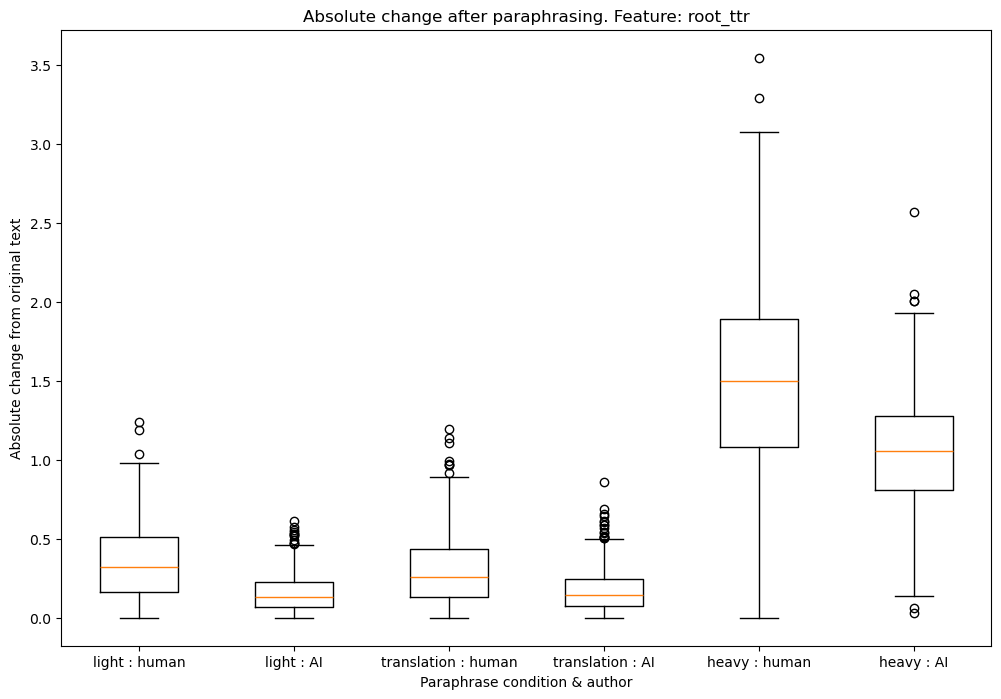

In [5]:
# specify feature
feature = "root_ttr"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

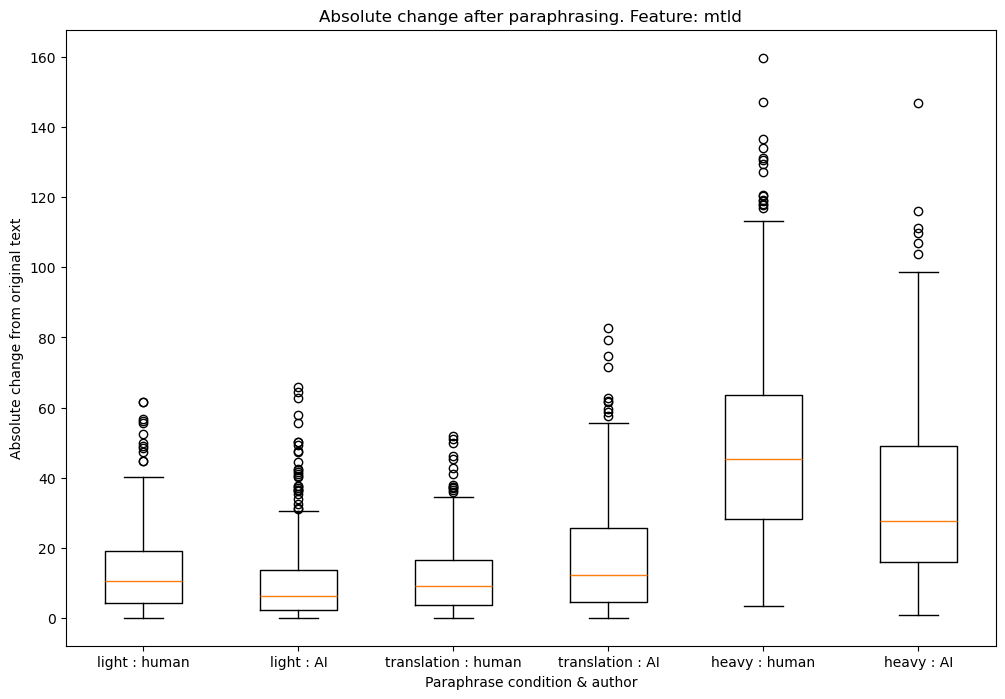

In [105]:
# specify feature
feature = "mtld"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

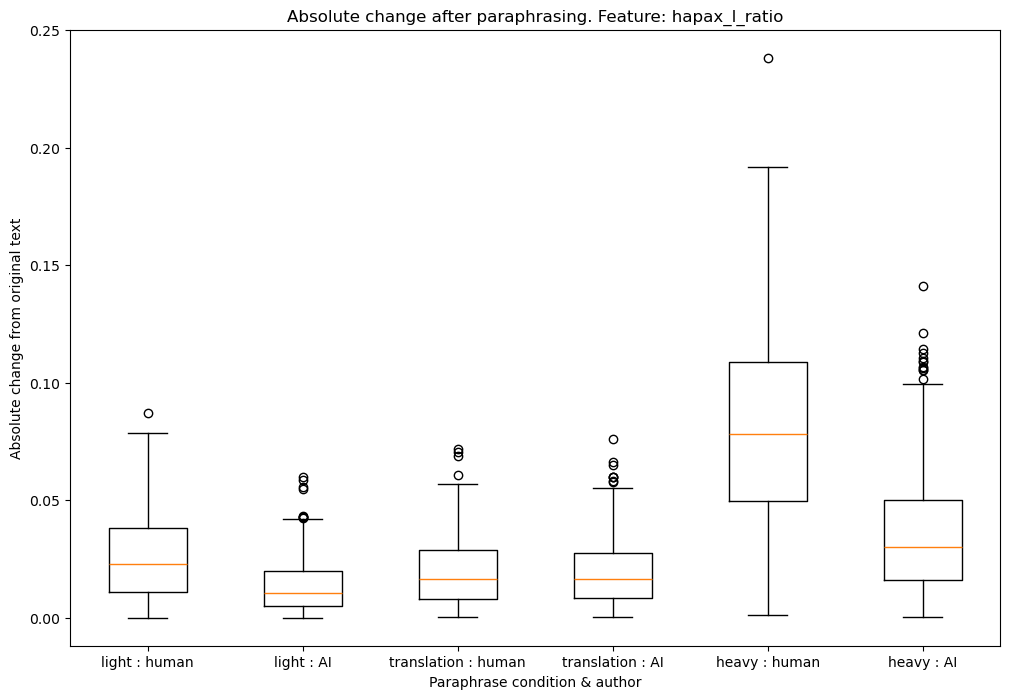

In [106]:
# specify feature
feature = "hapax_l_ratio"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

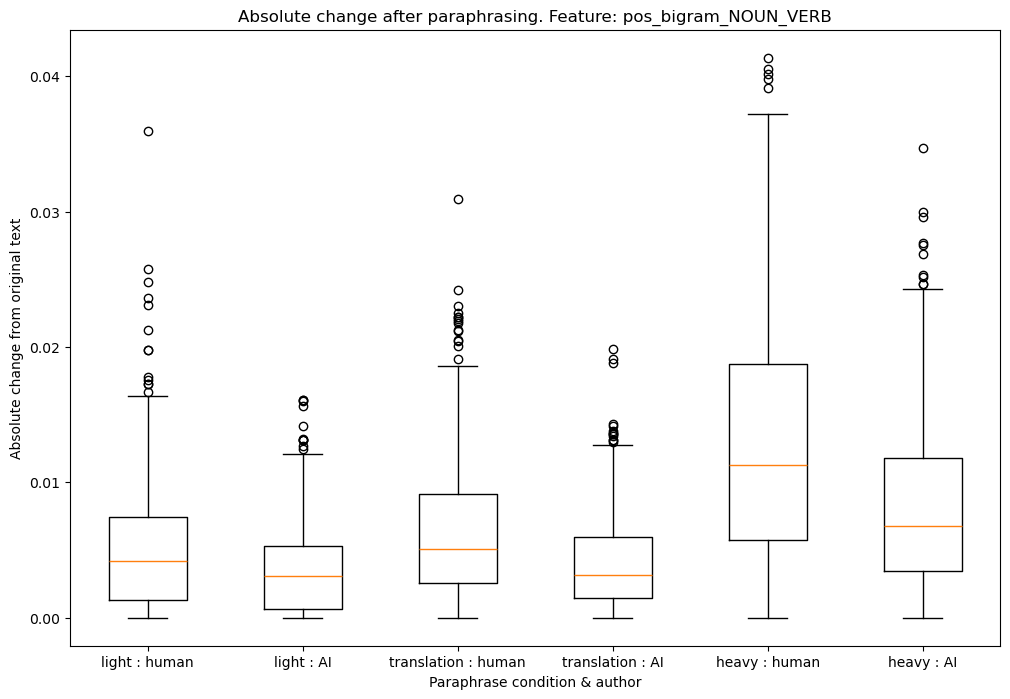

In [107]:
# specify feature
feature = "pos_bigram_NOUN_VERB"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

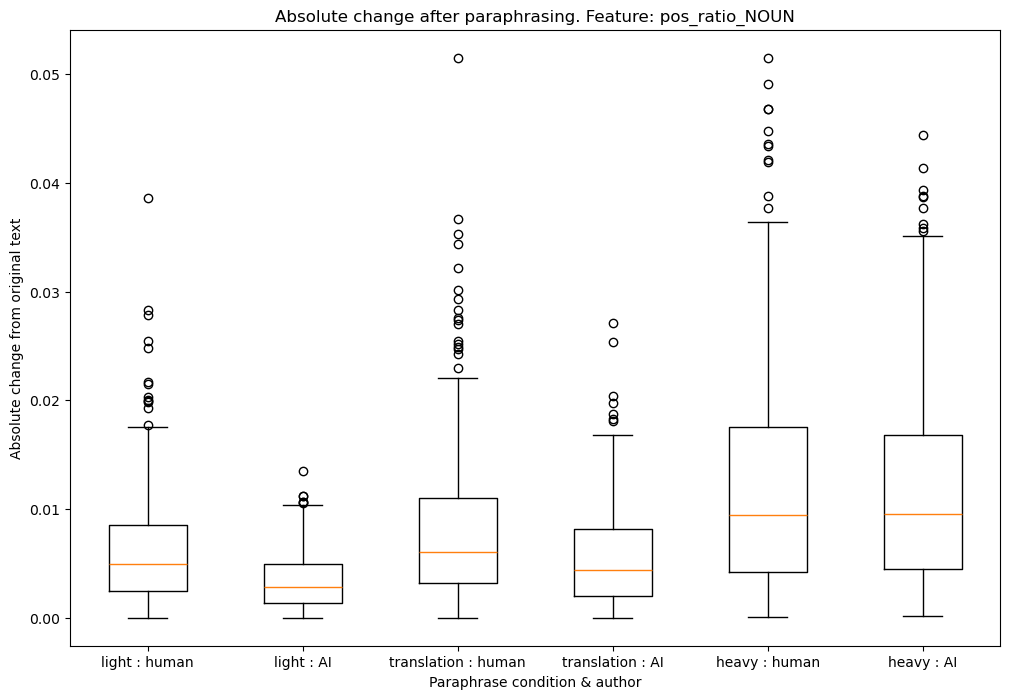

In [108]:
# specify feature
feature = "pos_ratio_NOUN"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

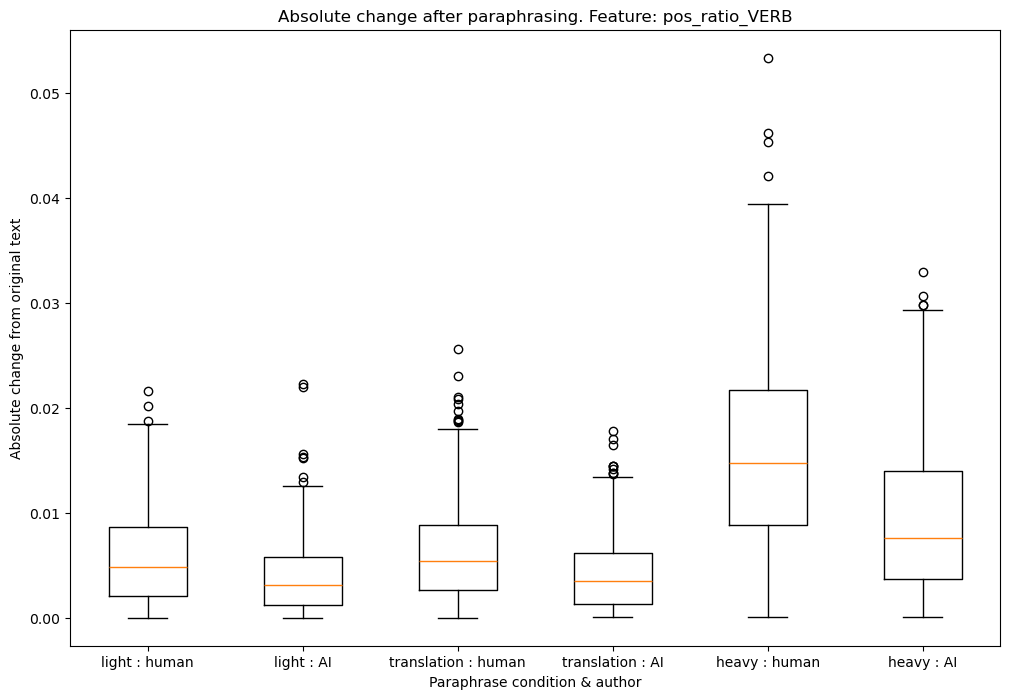

In [109]:
# specify feature
feature = "pos_ratio_VERB"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

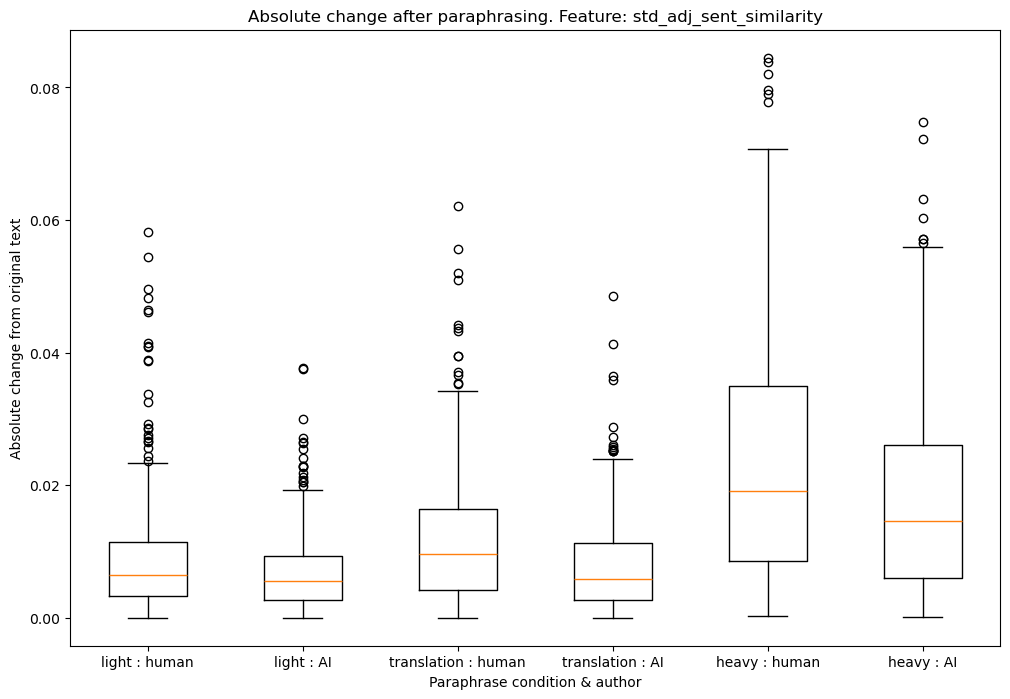

In [110]:
# specify feature
feature = "std_adj_sent_similarity"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

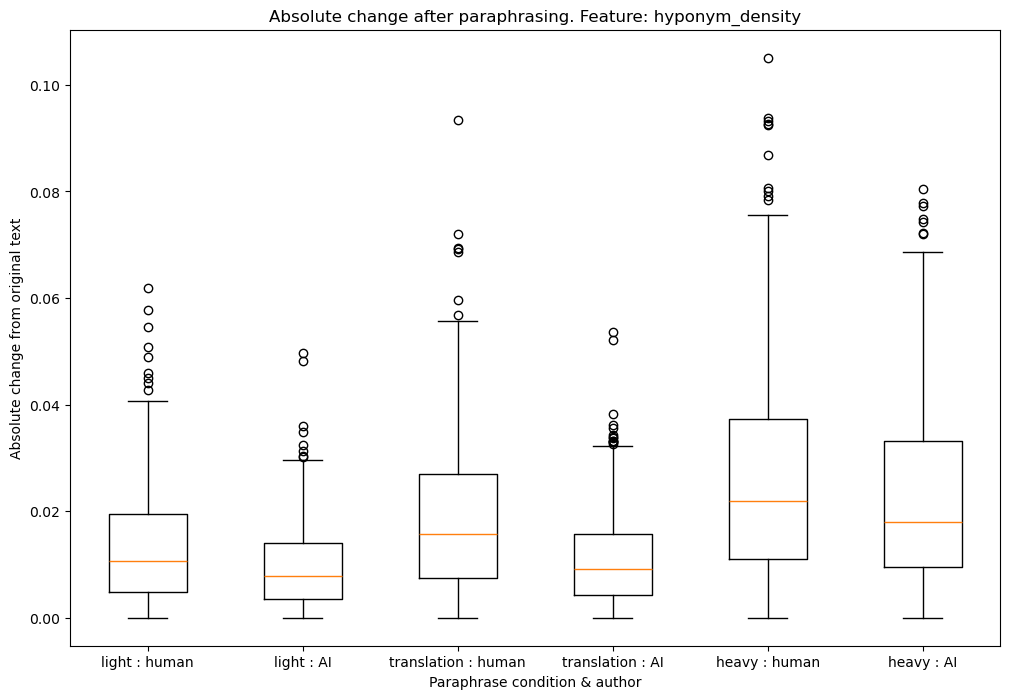

In [111]:
# specify feature
feature = "hyponym_density"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

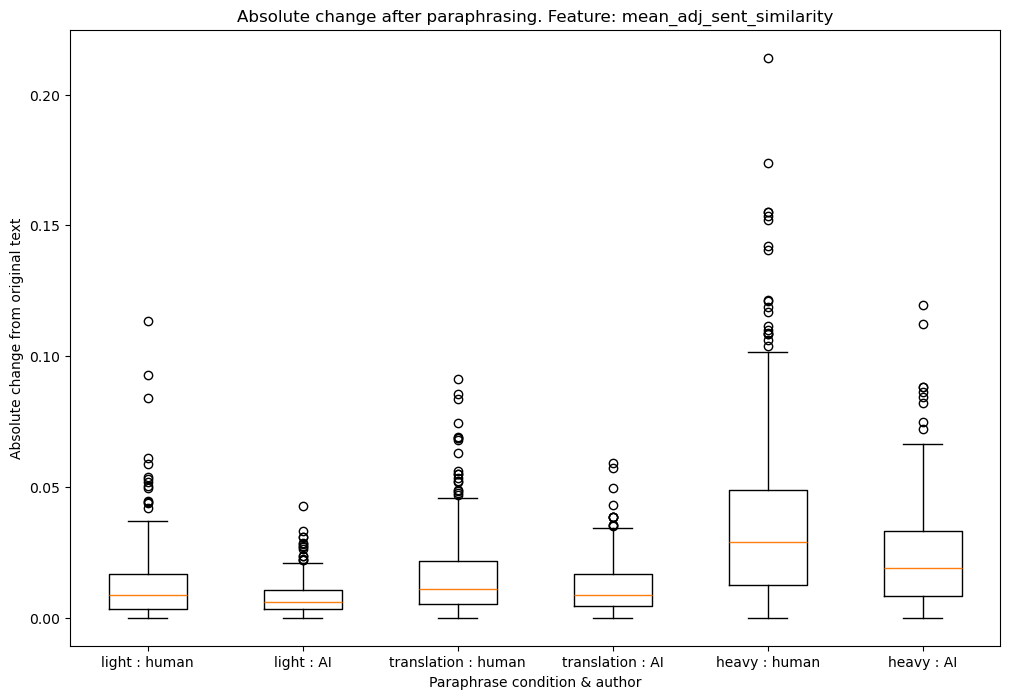

In [112]:
# specify feature
feature = "mean_adj_sent_similarity"

# filter main df to this feature
plot_stats = obj_3_changes_main[
    obj_3_changes_main["feature"] == feature
].copy()

# set order light > trans > heavy
conditions = ["light", "translation", "heavy"]

# initialise lists for plotting data
plot_data = []
plot_labels = []

# loop through paraphrase conditions
for condition in conditions:

    # and authors...
    for author in ["human", "AI"]:

        # and get absolute changes for this 
        # condition and author
        values = plot_stats.loc[
            (plot_stats["condition"] == condition) & 
            (plot_stats["author"] == author),
            "abs_delta"
        ].dropna()

        # and now add these values to the list
        plot_data.append(values)
        plot_labels.append(f"{condition} : {author}")

# create fig
plt.figure(figsize = (12, 8))
# draw plots
plt.boxplot(plot_data, tick_labels = plot_labels)

plt.title(f"Absolute change after paraphrasing. Feature: {feature}")
plt.xlabel("Paraphrase condition & author")
plt.ylabel("Absolute change from original text")
plt.show()   

___

# Final analysis

We have plots that showcase the effect of paraphrasing on various features. Lets finish this objective by looking at the top 5 features per feature type and the top 15 features overall as indicated in objective 2.

In [5]:
# top 15 overall features
top_15 = [
    "mtld", "root_ttr", "hapax_l_ratio", "lower_ratio", "alpha_ratio",
    "upper_ratio", "pos_bigram_NOUN_VERB", "std_sentence_length", 
    "pos_ratio_NOUN", "punct_ratio", "pos_ratio_VERB", "pos_bigram_NOUN_AUX", 
    "func_ratio_to", "pos_bigram_PUNCT_PRON", "dependency_ratio_nmod"
]

# and top 5 for each feature set
top_5_surface = [
     "mtld", "root_ttr", "hapax_l_ratio", "lower_ratio", "alpha_ratio"
]

top_5_syntactic = [
    "pos_bigram_NOUN_VERB", "pos_ratio_NOUN", "pos_ratio_VERB", 
    "pos_bigram_NOUN_AUX", "pos_bigram_PUNCT_PRON"
]

top_5_semantic = [
    "std_adj_sent_similarity", "hyponym_density", "mean_adj_sent_similarity",
    "hypernym_density", "mean_embedding_variance"
]

Now want summary DFs for each group above.

In [6]:
# top 15 features
# get stats for features in top 15
obj_3_top_15_stats = (
    obj_3_stats[obj_3_stats["feature"].isin(top_15)]
    .sort_values(
        # sort by feature then by median abs change
        ["feature", "median_abs_delta"],
        ascending = [True, False]
    )
    .reset_index(drop = True)
)

# top 5 surface
obj_3_top_5_surface = (
    obj_3_stats[obj_3_stats["feature"].isin(top_5_surface)]
    .sort_values(
        ["feature", "median_abs_delta"],
        ascending = [True, False]
    )
    .reset_index(drop = True)
)

# top 5 syntactic
obj_3_top_5_syntactic = (
    obj_3_stats[obj_3_stats["feature"].isin(top_5_syntactic)]
    .sort_values(
        ["feature", "median_abs_delta"],
        ascending = [True, False]
    )
    .reset_index(drop = True)
)

# top 5 semantic
obj_3_top_5_semantic = (
    obj_3_stats[obj_3_stats["feature"].isin(top_5_semantic)]
    .sort_values(
        ["feature", "median_abs_delta"],
        ascending = [True, False]
    )
    .reset_index(drop = True)
)

In [30]:
obj_3_top_15_stats

,feature_group,feature,author,condition,n,median_delta,mean_delta,median_abs_delta,mean_abs_delta
0,surface,alpha_ratio,human,heavy,398,0.018918,0.019190,0.018918,0.019313
1,surface,alpha_ratio,AI,heavy,399,0.008567,0.007956,0.008592,0.008682
2,surface,alpha_ratio,human,light,398,0.004571,0.004556,0.004644,0.004928
3,surface,alpha_ratio,human,translation,398,0.004286,0.004591,0.004500,0.005429
4,surface,alpha_ratio,AI,light,399,0.001439,0.001538,0.001787,0.002304
...,...,...,...,...,...,...,...,...,...
85,surface,upper_ratio,human,translation,398,-0.001022,-0.001075,0.001343,0.001904
86,surface,upper_ratio,AI,heavy,399,-0.000762,-0.000826,0.000906,0.001113
87,surface,upper_ratio,human,light,398,-0.000076,-0.000001,0.000451,0.000803
88,surface,upper_ratio,AI,translation,399,-0.000386,-0.000419,0.000422,0.000543


In [32]:
obj_3_top_5_surface

,feature_group,feature,author,condition,n,median_delta,mean_delta,median_abs_delta,mean_abs_delta
0,surface,alpha_ratio,human,heavy,398,0.018918,0.019190,0.018918,0.019313
1,surface,alpha_ratio,AI,heavy,399,0.008567,0.007956,0.008592,0.008682
2,surface,alpha_ratio,human,light,398,0.004571,0.004556,0.004644,0.004928
3,surface,alpha_ratio,human,translation,398,0.004286,0.004591,0.004500,0.005429
4,surface,alpha_ratio,AI,light,399,0.001439,0.001538,0.001787,0.002304
5,surface,alpha_ratio,AI,translation,399,-0.000043,0.000076,0.001449,0.001713
6,surface,hapax_l_ratio,human,heavy,398,0.078020,0.080122,0.078020,0.080565
7,surface,hapax_l_ratio,AI,heavy,399,0.027772,0.029421,0.030130,0.035128
8,surface,hapax_l_ratio,human,light,398,0.022067,0.022816,0.022913,0.025865
9,surface,hapax_l_ratio,human,translation,398,0.003117,0.003930,0.016615,0.019901


In [34]:
obj_3_top_5_syntactic

,feature_group,feature,author,condition,n,median_delta,mean_delta,median_abs_delta,mean_abs_delta
0,syntactic,pos_bigram_NOUN_AUX,human,heavy,398,0.004738,0.005943,0.007688,0.009575
1,syntactic,pos_bigram_NOUN_AUX,AI,heavy,399,0.000599,0.000272,0.005635,0.007015
2,syntactic,pos_bigram_NOUN_AUX,human,translation,398,-0.000094,-0.000278,0.003605,0.004746
3,syntactic,pos_bigram_NOUN_AUX,human,light,398,0.000053,-0.000035,0.003131,0.003575
4,syntactic,pos_bigram_NOUN_AUX,AI,translation,399,-0.000896,-0.001355,0.002947,0.004009
5,syntactic,pos_bigram_NOUN_AUX,AI,light,399,0.000209,0.000289,0.002831,0.002909
6,syntactic,pos_bigram_NOUN_VERB,human,heavy,398,0.010870,0.011397,0.011267,0.013118
7,syntactic,pos_bigram_NOUN_VERB,AI,heavy,399,0.004428,0.004291,0.006810,0.008376
8,syntactic,pos_bigram_NOUN_VERB,human,translation,398,0.002972,0.002777,0.005071,0.006434
9,syntactic,pos_bigram_NOUN_VERB,human,light,398,0.002729,0.002666,0.004167,0.005275


In [35]:
obj_3_top_5_semantic

,feature_group,feature,author,condition,n,median_delta,mean_delta,median_abs_delta,mean_abs_delta
0,semantic,hypernym_density,human,heavy,398,-1.069312e-02,-0.010452,0.021944,0.027719
1,semantic,hypernym_density,AI,heavy,399,-9.011858e-03,-0.009044,0.020058,0.023404
2,semantic,hypernym_density,human,translation,398,-1.802147e-03,-0.001585,0.015635,0.017827
3,semantic,hypernym_density,human,light,398,-4.056620e-03,-0.004156,0.010376,0.012760
4,semantic,hypernym_density,AI,translation,399,-2.801120e-04,0.000231,0.008604,0.010369
5,semantic,hypernym_density,AI,light,399,-4.848663e-03,-0.005036,0.007520,0.009465
6,semantic,hyponym_density,human,heavy,398,-1.263473e-03,0.000042,0.021825,0.026975
7,semantic,hyponym_density,AI,heavy,399,-7.060859e-03,-0.006538,0.017977,0.022380
8,semantic,hyponym_density,human,translation,398,4.324292e-03,0.003394,0.015630,0.018964
9,semantic,hyponym_density,human,light,398,-6.695722e-04,-0.000665,0.010703,0.013403


And now lets try for some summaries.

In [42]:
# specify group to table
group = top_5_surface

# get features in group above
obj_3_summary = obj_3_stats[obj_3_stats["feature"].isin(group)].copy()

# reshape so feature per row
# key value we want is median absolute delta
obj_3_summary = obj_3_summary.pivot(
    index = ["feature_group", "feature"],
    columns = ["author", "condition"],
    values = "median_abs_delta"
)

# combine authors and conditions
obj_3_summary.columns = [
    f"{author}_{condition}"
    for author, condition in obj_3_summary.columns
]

# reset index
obj_3_summary = obj_3_summary.reset_index()
# put columns in order
obj_3_summary = obj_3_summary[
    [
        "feature_group", "feature", "human_light", "human_translation",
        "human_heavy", "AI_light", "AI_translation", "AI_heavy"
    ]
]
# 3dp
obj_3_summary = obj_3_summary.round(3)
obj_3_summary

,feature_group,feature,human_light,human_translation,human_heavy,AI_light,AI_translation,AI_heavy
0,surface,alpha_ratio,0.005,0.005,0.019,0.002,0.001,0.009
1,surface,hapax_l_ratio,0.023,0.017,0.078,0.011,0.017,0.030
2,surface,lower_ratio,0.005,0.005,0.021,0.002,0.002,0.009
3,surface,mtld,10.351,8.976,45.168,6.195,12.317,27.552
4,surface,root_ttr,0.318,0.260,1.497,0.134,0.146,1.058


In [43]:
# specify group to table
group = top_5_syntactic

# get features in group above
obj_3_summary = obj_3_stats[obj_3_stats["feature"].isin(group)].copy()

# reshape so feature per row
# key value we want is median absolute delta
obj_3_summary = obj_3_summary.pivot(
    index = ["feature_group", "feature"],
    columns = ["author", "condition"],
    values = "median_abs_delta"
)

# combine authors and conditions
obj_3_summary.columns = [
    f"{author}_{condition}"
    for author, condition in obj_3_summary.columns
]

# reset index
obj_3_summary = obj_3_summary.reset_index()
# put columns in order
obj_3_summary = obj_3_summary[
    [
        "feature_group", "feature", "human_light", "human_translation",
        "human_heavy", "AI_light", "AI_translation", "AI_heavy"
    ]
]
# 3dp
obj_3_summary = obj_3_summary.round(3)
obj_3_summary

,feature_group,feature,human_light,human_translation,human_heavy,AI_light,AI_translation,AI_heavy
0,syntactic,pos_bigram_NOUN_AUX,0.003,0.004,0.008,0.003,0.003,0.006
1,syntactic,pos_bigram_NOUN_VERB,0.004,0.005,0.011,0.003,0.003,0.007
2,syntactic,pos_bigram_PUNCT_PRON,0.004,0.005,0.008,0.000,0.002,0.004
3,syntactic,pos_ratio_NOUN,0.005,0.006,0.009,0.003,0.004,0.010
4,syntactic,pos_ratio_VERB,0.005,0.005,0.015,0.003,0.003,0.008


In [8]:
# specify group to table
group = top_5_semantic

# get features in group above
obj_3_summary = obj_3_stats[obj_3_stats["feature"].isin(group)].copy()

# reshape so feature per row
# key value we want is median absolute delta
obj_3_summary = obj_3_summary.pivot(
    index = ["feature_group", "feature"],
    columns = ["author", "condition"],
    values = "median_abs_delta"
)

# combine authors and conditions
obj_3_summary.columns = [
    f"{author}_{condition}"
    for author, condition in obj_3_summary.columns
]

# reset index
obj_3_summary = obj_3_summary.reset_index()
# put columns in order
obj_3_summary = obj_3_summary[
    [
        "feature_group", "feature", "human_light", "human_translation",
        "human_heavy", "AI_light", "AI_translation", "AI_heavy"
    ]
]
# 3dp
obj_3_summary = obj_3_summary.round(5)
obj_3_summary

,feature_group,feature,human_light,human_translation,human_heavy,AI_light,AI_translation,AI_heavy
0,semantic,hypernym_density,0.01038,0.01564,0.02194,0.00752,0.00860,0.02006
1,semantic,hyponym_density,0.01070,0.01563,0.02183,0.00785,0.00913,0.01798
2,semantic,mean_adj_sent_similarity,0.00858,0.01115,0.02888,0.00612,0.00887,0.01890
3,semantic,mean_embedding_variance,0.00002,0.00002,0.00006,0.00001,0.00002,0.00005
4,semantic,std_adj_sent_similarity,0.00650,0.00966,0.01909,0.00550,0.00578,0.01463
